In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

MAIN_PATH = Path("../data/processed/main_df.csv")
ORDER_ITEMS_AND_PRODUCTS_PATH = Path("../data/processed/order_items_and_products_feature_engineered_df.csv")

date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date",
             "review_creation_date", "review_answer_timestamp"]

main_df = pd.read_csv(MAIN_PATH, parse_dates=date_cols)
order_items_and_products_fe = pd.read_csv(ORDER_ITEMS_AND_PRODUCTS_PATH)

# Main Dataframe Analysis

In [2]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,total_order_price,total_freight,num_items,total_payment_value,max_payment_installment,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,29.99,8.72,1.0,38.71,1.0,Voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,118.70,22.76,1.0,141.46,1.0,Boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,NaN,NaN,2018-08-18,2018-08-22 19:07:58,159.90,19.22,1.0,179.12,3.0,Credit Card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,45.00,27.20,1.0,72.20,1.0,Credit Card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,NaN,NaN,2018-02-17,2018-02-18 13:02:51,19.90,8.72,1.0,28.62,1.0,Credit Card


In [3]:
# data types
main_df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
review_id                                   str
review_score                            float64
review_comment_title                        str
review_comment_message                      str
review_creation_date             datetime64[us]
review_answer_timestamp          datetime64[us]
total_order_price                       float64
total_freight                           float64
num_items                               

In [4]:
# summary
main_df.describe(include=["int64", "float64"])

,customer_zip_code_prefix,review_score,total_order_price,total_freight,num_items,total_payment_value,max_payment_installment
count,99441.000000,98673.000000,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000
mean,35137.474583,4.086853,137.754076,22.823562,1.141731,160.990267,2.930521
std,29797.938996,1.347287,210.645145,21.650909,0.538452,221.951257,2.715685
min,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000
25%,11347.000000,4.000000,45.900000,13.850000,1.000000,62.010000,1.000000
50%,24416.000000,5.000000,86.900000,17.170000,1.000000,105.290000,2.000000
75%,58900.000000,5.000000,149.900000,24.040000,1.000000,176.970000,4.000000
max,99990.000000,5.000000,13440.000000,1794.960000,21.000000,13664.080000,24.000000


## Missing Values Analysis

How many missing values? What are the top ones?

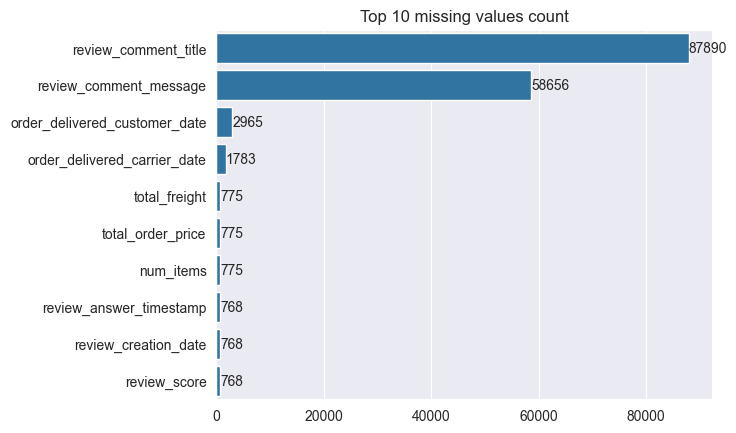

In [5]:
top_ten_missing_values = main_df.isna().sum().sort_values(ascending=False).nlargest(10)

sns.set_style("darkgrid")

ax = sns.barplot(top_ten_missing_values, orient="h")
ax.bar_label(ax.containers[0], fontsize=10)
ax.set_title("Top 10 missing values count")
plt.show()

## Missing values as a percentage of total rows

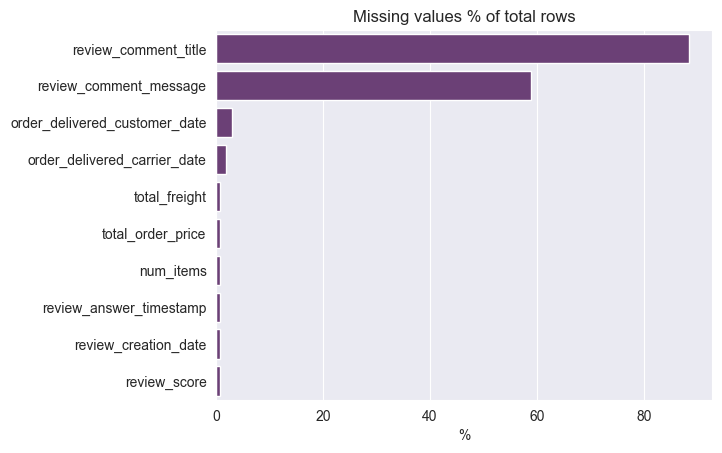

In [6]:
rows, cols = main_df.shape
top_ten_missing_values_perc = (main_df.isna().sum() / rows).sort_values(ascending=False).nlargest(10) * 100

ax = sns.barplot(top_ten_missing_values_perc, errorbar=None, orient="h", color="#70377f")
ax.set_title("Missing values % of total rows")
ax.set_xlabel("%")
plt.show()

## Target Variable Analysis (Review Scores)

What are review_score counts?

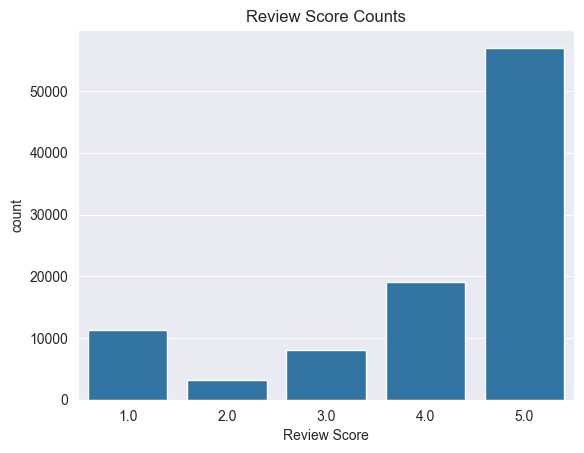

In [7]:
review_score_counts = main_df.review_score.value_counts()
ax = sns.barplot(review_score_counts)
ax.set_xlabel("Review Score")
ax.set_title("Review Score Counts")
plt.show()

How is it divided in terms of percentages?

Text(0.5, 1.0, 'Review Score %')

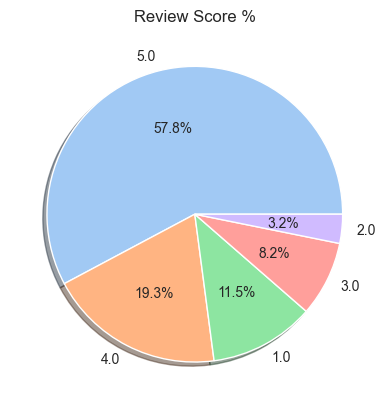

In [8]:
review_score_counts_perc = main_df.review_score.value_counts(normalize=True)
review_score_colors = sns.color_palette("pastel")

plt.pie(review_score_counts_perc.values, labels=review_score_counts_perc.index, autopct="%1.1f%%", colors=review_score_colors, shadow=True)
plt.title("Review Score %")

## Numerical Features Analysis

In [9]:
# numerical columns
main_df.select_dtypes(include=["float64", "int64"]).columns

Index(['customer_zip_code_prefix', 'review_score', 'total_order_price',
       'total_freight', 'num_items', 'total_payment_value',
       'max_payment_installment'],
      dtype='str')

Is "total_order_price" normally distributed?

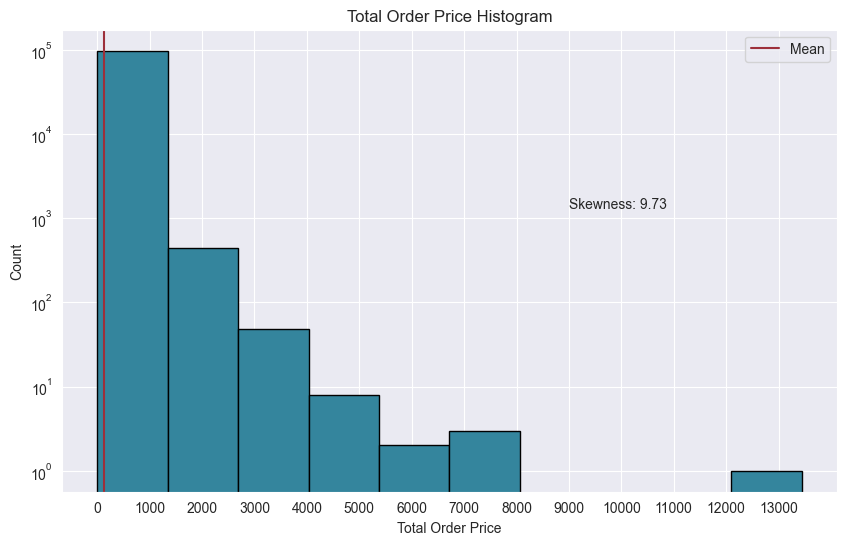

In [10]:
total_order_price_stats = main_df.total_order_price.agg(["mean", np.std, "skew"])

plt.figure(figsize=(10, 6))
plt.hist(main_df.total_order_price.values, color="#34859d", edgecolor="black")
plt.xticks(np.arange(0, main_df.total_order_price.max(), 1000))
plt.text(9000, 1300, f"Skewness: {round(total_order_price_stats.iloc[2], 2)}")
plt.axvline(total_order_price_stats.iloc[0], color="#9d303b", label="Mean")
plt.yscale(value="log")
plt.xlabel("Total Order Price")
plt.ylabel("Count")
plt.title("Total Order Price Histogram")
plt.legend()
plt.show()

How are the other numerical columns distributed? Are there outliers?

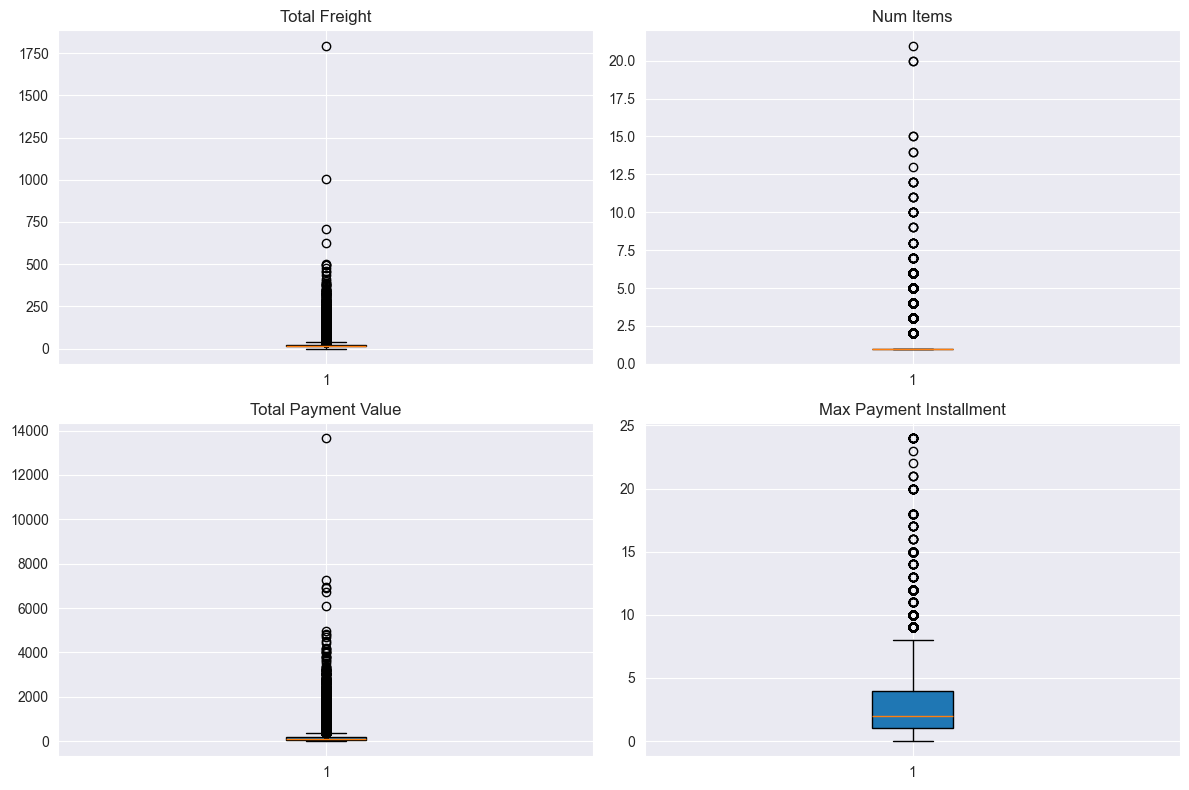

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

cols = ["total_freight", "num_items", "total_payment_value", "max_payment_installment"]

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(main_df[col].dropna(), patch_artist=True)
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout()

## Categorical Features Analysis

In [12]:
main_df.select_dtypes(include="str").columns

Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_city', 'customer_state', 'review_id', 'review_comment_title',
       'review_comment_message', 'payment_type'],
      dtype='str')

What are "order_status" counts?

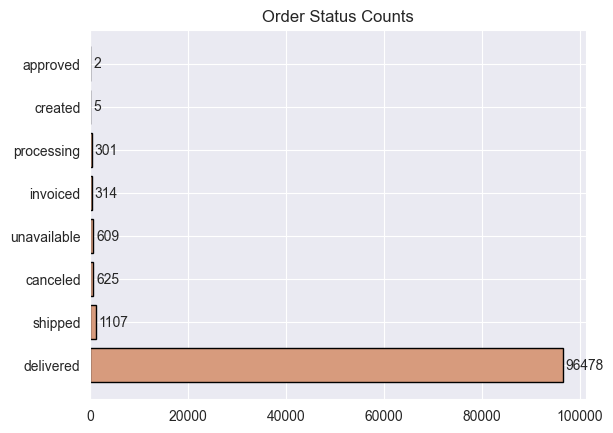

In [13]:
order_status_counts = main_df.order_status.value_counts()
order_status_bar = plt.barh(order_status_counts.index, order_status_counts.values, edgecolor="black", color="#d79b7d")
plt.bar_label(order_status_bar, padding=2)
plt.title("Order Status Counts")
plt.show()

Are there cities that pay more than others?

Text(0, 0.5, 'Mean Total Order Price')

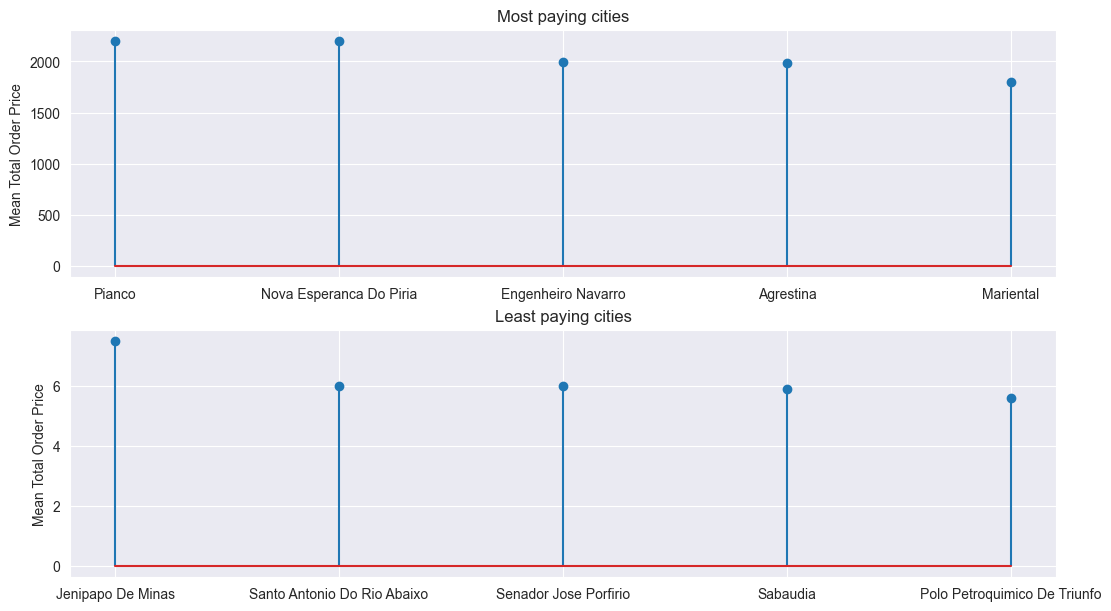

In [14]:
cities_order_prices = main_df.groupby("customer_city")["total_order_price"].mean().sort_values(ascending=False).dropna()

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(11, 6))

axes[0].stem(cities_order_prices.head().index, cities_order_prices.head().values)
axes[0].set_title("Most paying cities")
axes[0].set_ylabel("Mean Total Order Price")
axes[1].stem(cities_order_prices.tail().index, cities_order_prices.tail().values)
axes[1].set_title("Least paying cities")
axes[1].set_ylabel("Mean Total Order Price")

Does payment type influence the number of items ordered?

Text(0.5, 1.0, 'Mean Number Of Items Per Payment Type')

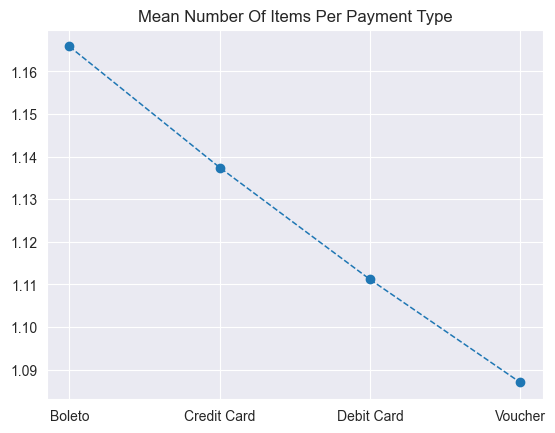

In [15]:
payment_type_num_items = main_df.groupby("payment_type")["num_items"].mean().dropna()

plt.plot(payment_type_num_items.index, payment_type_num_items.values, linestyle="dashed", linewidth=1.1, marker="o")
plt.title("Mean Number Of Items Per Payment Type")


## Target Relationships

Do payment types influence review scores (target)?

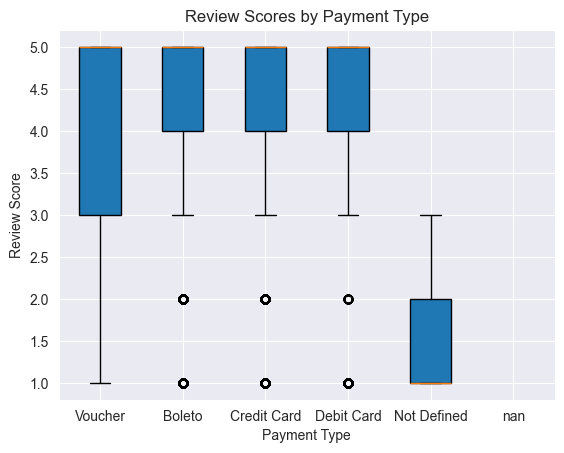

In [16]:
payment_types = main_df.payment_type.unique()
data = [main_df[main_df.payment_type == pt]["review_score"].dropna() for pt in payment_types]

plt.boxplot(data, patch_artist=True, tick_labels=payment_types)
plt.title("Review Scores by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Review Score")
plt.show()

Does order status influence review scores?

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

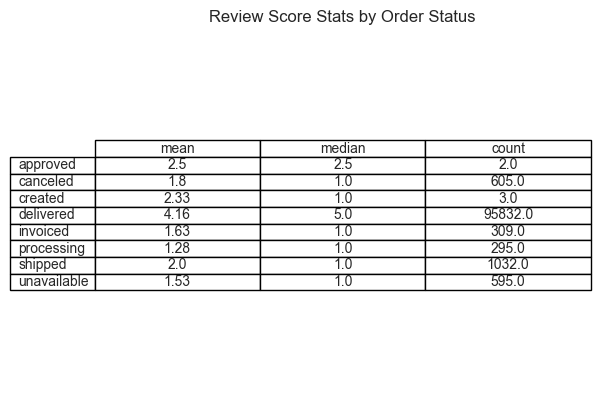

In [17]:
order_status_target_stats = main_df.groupby("order_status")["review_score"].agg(["mean", "median", "count"]).reset_index().round(2)

order_status_target_stats
plt.table(cellText=order_status_target_stats.iloc[:, 1:].values, cellLoc="center", 
          rowLabels=order_status_target_stats["order_status"], colLabels=order_status_target_stats.columns[1:], loc="center")
plt.title("Review Score Stats by Order Status")
plt.axis("off")

## Correlation Analysis

Are some numerical features more correlated to the target variable?

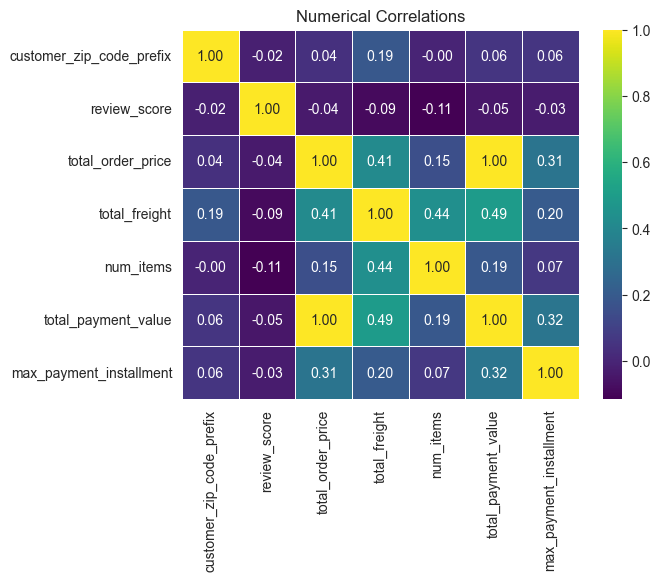

In [18]:
numerical_corrs = main_df.corr(method="pearson", numeric_only=True)

sns.heatmap(numerical_corrs, annot=True, fmt=".2f", linewidth=0.5, cmap="viridis")
plt.title("Numerical Correlations")
plt.show()

## Temporal Analysis

Did people purchase more in certain years?

Text(0.5, 1.0, 'Purchase %')

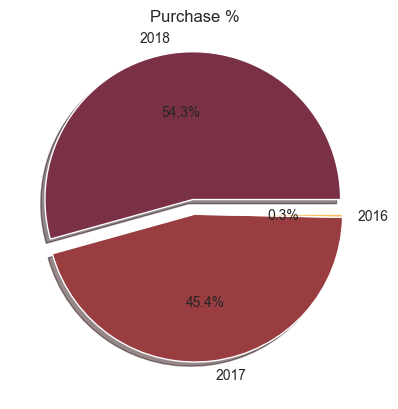

In [19]:
purchases_per_year = main_df.order_purchase_timestamp.dt.year.value_counts(normalize=True)

plt.pie(purchases_per_year.values, autopct="%1.1f%%", labels=purchases_per_year.index, shadow=True, explode=(0.1, 0, 0), 
        colors=["#7a3045", "#993d41", "#fbb954"])
plt.title("Purchase %")

Do orders delivered after "estimated delivery date" get lower review scores?

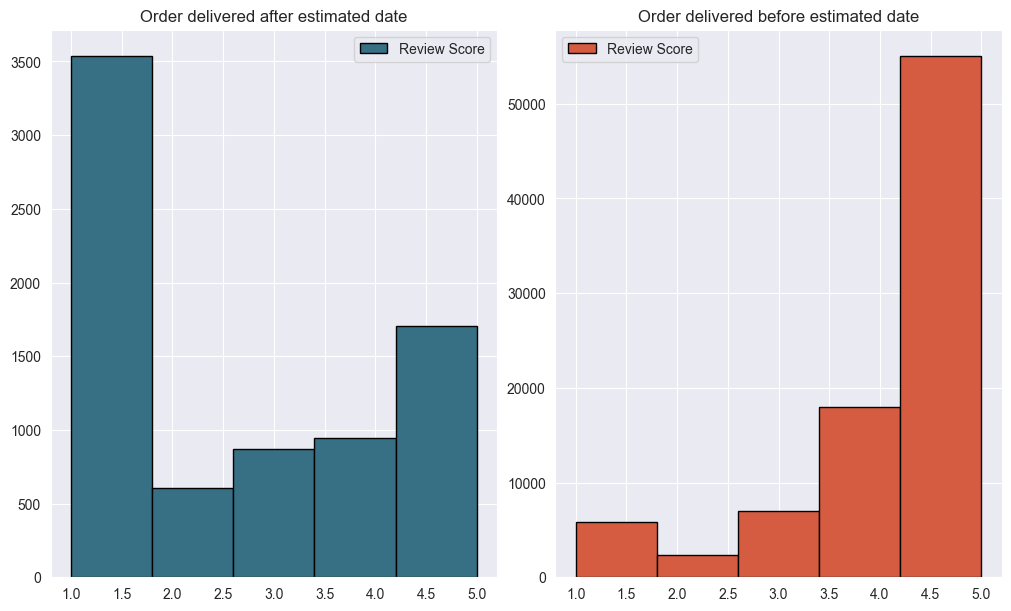

In [20]:
orders_after_estimated_delivery = main_df[main_df.order_delivered_customer_date > main_df.order_estimated_delivery_date]
orders_before_estimated_delivery = main_df[main_df.order_delivered_customer_date < main_df.order_estimated_delivery_date]

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(10, 6))
axes[0].hist(orders_after_estimated_delivery.review_score, bins=5, edgecolor="black", color="#376f85", label="Review Score")
axes[0].set_title("Order delivered after estimated date")
axes[0].legend()
axes[1].hist(orders_before_estimated_delivery.review_score, bins=5, edgecolor="black", color="#d65c41", label="Review Score")
axes[1].set_title("Order delivered before estimated date")
axes[1].legend()
plt.show()

# Order Items And Products Analysis

In [21]:
# df
order_items_and_products_fe.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_spend,price_category,volume,density,freight_per_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,Cool Stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,72.19,Medium,3528.0,0.18,0.23
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,Pet Shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,259.83,Medium,60000.0,0.50,0.08
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,Moveis Decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,216.87,Medium,14157.0,0.22,0.09
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,Perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,25.78,Low,2400.0,0.08,0.98
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,Ferramentas Jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,218.04,Medium,42000.0,0.09,0.09


In [22]:
# basic stats
order_items_and_products_fe.describe(include=["int64", "float64"])

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_spend,volume,density,freight_per_price
count,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,112650.000000,112632.000000,112632.000000,112650.000000
mean,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546,140.644059,15243.709567,0.191661,0.320799
std,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268,190.724394,23418.524686,0.784476,0.349967
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,6.080000,168.000000,0.000000,0.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,55.220000,2851.500000,0.070000,0.130000
50%,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,92.320000,6480.000000,0.110000,0.230000
75%,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,157.937500,18375.000000,0.190000,0.390000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,6929.310000,296208.000000,85.230000,26.240000


## Numerical Features Analysis

Is price normally distributed? What are the maximum and the minimum?

Text(0.5, 1.0, 'Price Histogram')

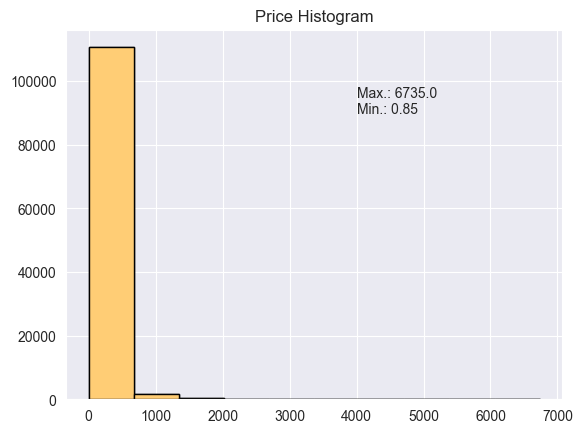

In [23]:
plt.hist(order_items_and_products_fe.price, edgecolor="black", color="#ffcd75")
max_price, min_price = order_items_and_products_fe.price.max(), order_items_and_products_fe.price.min()

plt.hist(order_items_and_products_fe.price, edgecolor="black", color="#ffcd75")
plt.text(4000, 95000, s=f"Max.: {max_price}")
plt.text(4000, 90000, s=f"Min.: {min_price}")
plt.title("Price Histogram")

Are product sizes roughly equal? How are they distributed?

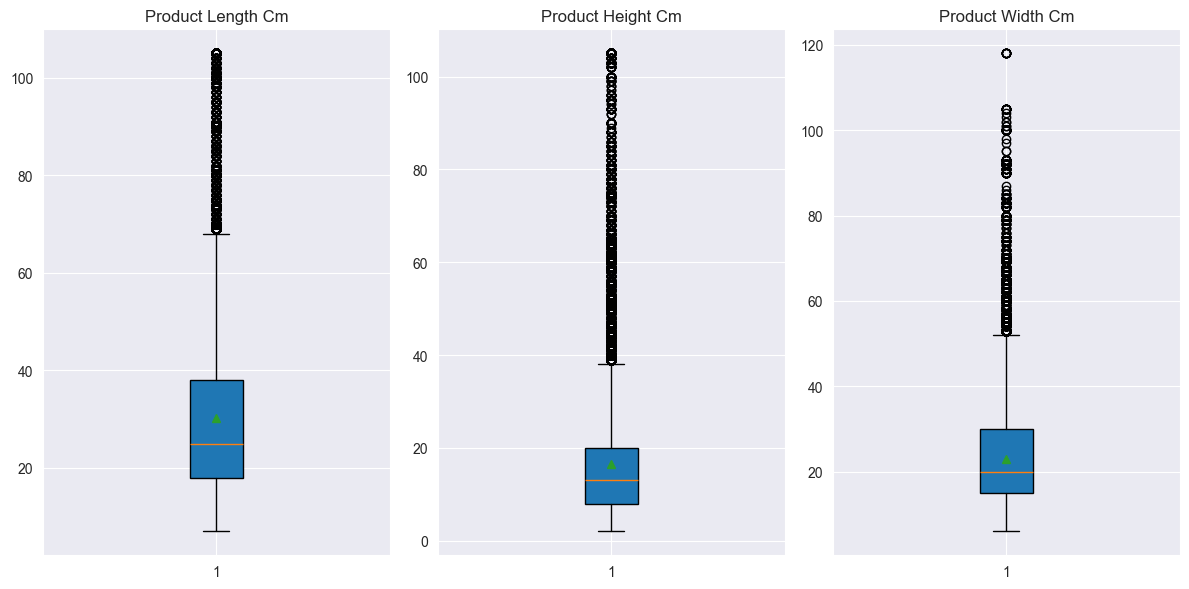

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

product_cols = ["product_length_cm", "product_height_cm", "product_width_cm"]

for ax, col in zip(axes, product_cols):
    ax.boxplot(order_items_and_products_fe[col].dropna(), patch_artist=True, showmeans=True)
    ax.set_title(f"{col.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

## Categorical Features Analysis

Which are the most bought product categories?

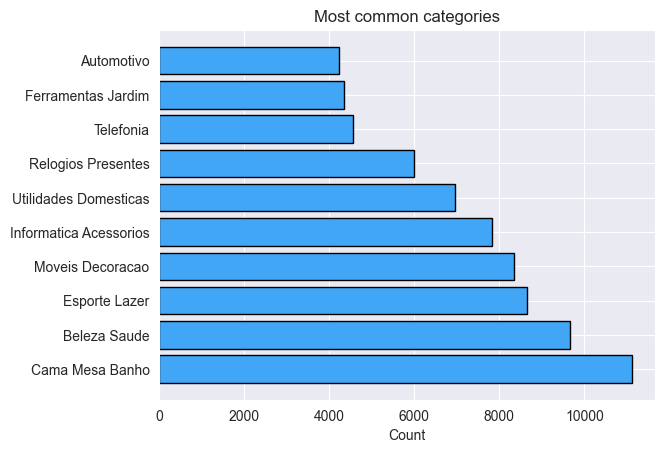

In [25]:
most_common_product_categories = order_items_and_products_fe.product_category_name.value_counts(ascending=False).nlargest(10)

plt.barh(most_common_product_categories.index, most_common_product_categories.values, edgecolor="black", color="#41a6f6")
plt.xlabel("Count")
plt.title("Most common categories")

Does higher price mean heavier volume, on average?

price_category
High      43320.616796
Low        6745.709618
Medium    18719.387952
Name: volume, dtype: float64

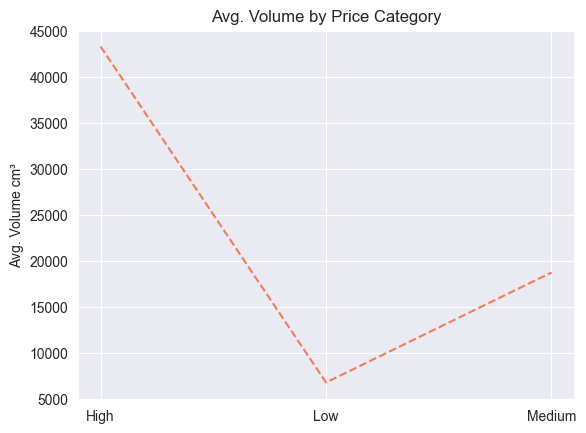

In [26]:
avg_volume_per_price_cat = order_items_and_products_fe.groupby("price_category")["volume"].mean()

plt.plot(avg_volume_per_price_cat.index, avg_volume_per_price_cat.values, linestyle="--", color="#ef7d57")
plt.title("Avg. Volume by Price Category")
plt.ylabel("Avg. Volume cm³")
avg_volume_per_price_cat

## Correlation Analysis

Does product description length increase with total spend?

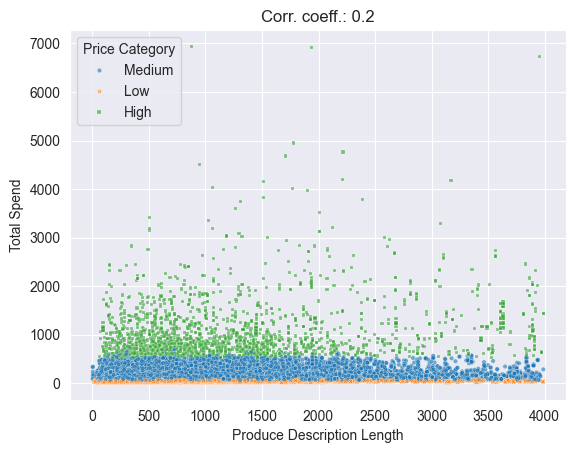

In [27]:
prod_desc_spend_corr = order_items_and_products_fe.product_description_lenght.corr(order_items_and_products_fe["total_spend"])

ax = sns.scatterplot(data=order_items_and_products_fe, x="product_description_lenght", y="total_spend", hue="price_category", style="price_category", s=10, alpha=0.6)
ax.set_title(f"Corr. coeff.: {round(prod_desc_spend_corr, 2)}")
ax.set_xlabel("Produce Description Length")
ax.set_ylabel("Total Spend")
ax.legend(title="Price Category")

Are freight value and price correlated?

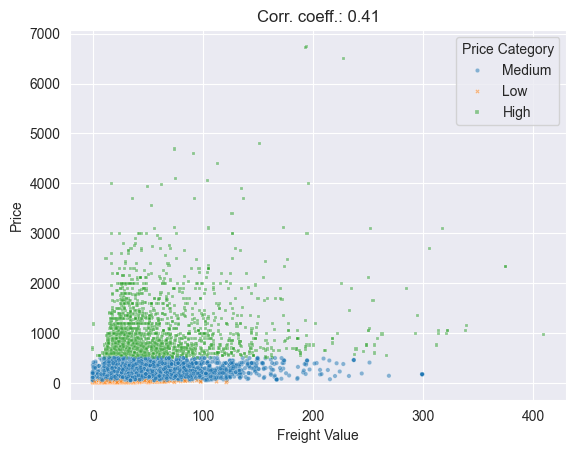

In [28]:
freight_value_price_corr = order_items_and_products_fe.freight_value.corr(order_items_and_products_fe.price)

ax = sns.scatterplot(data=order_items_and_products_fe, x="freight_value", y="price", hue="price_category", style="price_category", s=10, alpha=0.5)
ax.set_title(f"Corr. coeff.: {round(freight_value_price_corr, 2)}")
ax.set_xlabel("Freight Value")
ax.set_ylabel("Price")
ax.legend(title="Price Category")

## Main Dataframe Conclusions

1.	“review_comment_title” and “review_comment_message” are the features that have the most missing values, reaching more than 50k. This suggests that not all customers write a review after purchasing a product.
2.	The dataset is largely comprised of 4+ review scores, which together reach 77.1% of it. Importantly, there are many 1 review scores, making up 11.5% of the total dataset.
3.	Regarding numerical features analysis, price isn’t normally distributed. This is normal behaviour as not many people purchase high-priced products. This is further confirmed by low mean of 137.8.
Other numerical columns such as total freight, number of items and total payment value showed many outliers, as suggested by the many circles in the boxplots. As a result, the boxplots are heavily skewed to the right.
4.	Regarding categorical features analysis, the dataset remains largely made up of “delivered” entries, which makes sense for a Brazilian department store. 
Furthermore, some cities pay, on average, more than others in terms of orders. This is the case with Pianco, Nove Esperanca Do Piria and Engenheiro Navarro. Though the values were high, the entries might be small to be meaningful to draw conclusions.
Talking about payment types, these don’t influence in a meaningful way the number of items purchased, which range from ≈1.08 to ≈1.17.
5.	Despite small differences between payment types, review score distributions overlap heavily. To notice, review scores are negatively skewed, which confirms the 11.5% of 1 review scores in the dataset. 
Moreover, delivered orders show a relatively higher average review score (4.16), compared to other order statuses (2.5 for approved, 1.8 for canceled, 1.28 for processing). It is worthwhile to mention that the dataset is made up of delivered orders, with the remaining representing a small percentage. 
6.	All numerical features show a no-to-low correlation with the target variable (review score), evidenced by the correlation coefficients near 0.
7.	99.7% of the purchases were made in 2017 and 2018, with the remaining ones in 2016. Something to note is that orders delivered after the estimated date get lower review scores compared to the ones delivered before.
As an example, in the first case, 1 review score count is a bit more than 3500, while 5 review count is ≈1700. In the second case, 1 review score count is ≈500, while 5 review score count is more than 50k.


## Order Items and Products Dataset

1.	Numerical Features Analysis: price isn’t normally distributed, suggested by the right-skewed histogram. Furthermore, product sizes (length, height, width) show a few outliers. This suggests that large products exist in the dataset but represent a relatively small proportion of purchases, which makes sense because people generally buy simple products.
2.	Categorical Features Analysis: the most bought categories are cama mesa banho, Beleza saude and esporte lazer. Furthermore, a low price indicates a lower product volume, on average: low 6745.7, medium 18719.4 and high 43320.7.
3.	Correlation Analysis: product description length doesn’t increase meaningfully with total spend, as evidenced by the correlation coefficient of 0.2. A stronger, though not meaningful, correlation is between freight value and price (0.41).